In [1]:
%cd ..
from experiment_control.srs_microscope.srs_microscope import *

C:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


C:\Users\euyehara\experiment_control


C:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\cffi\cparser.py:436: UserWarning: #pragma in cdef() are entirely ignored. They should be removed for now, otherwise your code might behave differently in a future version of CFFI if #pragma support gets added. Note that '#pragma pack' needs to be replaced with the 'packed' keyword argument to cdef().
  warnings.warn(


Opening connnection to Keithley source meter
Opening connection to Agilent E3633A DC Power Supply


In [2]:
center_spot()

In [29]:
cam.close()

In [ ]:
VOA_volt = 2.33*u.V
ch_VOA.write(VOA_volt)

In [ ]:
HVA_volt = 0*u.V

daq_volt = HVA_to_daq(HVA_volt)
ch_VCSEL_MEMS.write(daq_volt)

In [ ]:
Vmon = (ch_HVA_Vmon.read())*100 

# Functions to add
    - plot sweep spectra
    - set vcsel wavelength (either source meter + power supply or daq) with delay comp
    - save spectra (wavvolt figures) as jpg

# Collect Wavvolt

In [2]:
sample_dir = "Dev1a_GS"
name = "GSDev1a_9.2mW_0-65V"

init_voltage = 0*u.V  # [V]
end_voltage = 65*u.V # [V]
increment = 1*u.V  # Voltage increment
voltage_list = np.arange(init_voltage.m, end_voltage.m+increment.m, increment.m) * u.V
osa_settings = {
    "rbw": 0.1*u.nm,
    "ref_level": -10*u.dimensionless,
    "wav_start": 1230*u.nm,
    "wav_stop": 1380*u.nm
}
num_avg=5

ds=generate_wavvolt(voltage_list, osa_settings, num_avg, sample_dir=sample_dir, name=name)

saving data to: 
C:\Users\euyehara\experiment_control\calibration_data\VCSEL_calibration\Sample_Dev1a_GS_2025-03-29-17-59-42\wavvoltdata_GSDev1a_9.2mW_0-65V_2025-03-31-18-15-06.h5
Voltage set: 0.0000 V...
Voltage measured: -0.1839 V


C:\Users\euyehara\experiment_control\experiment_control\srs_microscope\srs_microscope.py:1075: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  spectrum_array[ind, :] = np.reshape(spectra, (1, int(trace_len)))


Voltage set: 1.0000 V...
Voltage measured: 0.8352 V
Voltage set: 2.0000 V...
Voltage measured: 1.8413 V
Voltage set: 3.0000 V...
Voltage measured: 2.8539 V
Voltage set: 4.0000 V...
Voltage measured: 3.8085 V
Voltage set: 5.0000 V...
Voltage measured: 4.8404 V
Voltage set: 6.0000 V...
Voltage measured: 5.7950 V
Voltage set: 7.0000 V...
Voltage measured: 6.8592 V
Voltage set: 8.0000 V...
Voltage measured: 7.8202 V
Voltage set: 9.0000 V...
Voltage measured: 8.7360 V
Voltage set: 10.0000 V...
Voltage measured: 9.8131 V
Voltage set: 11.0000 V...
Voltage measured: 10.7806 V
Voltage set: 12.0000 V...
Voltage measured: 11.7867 V
Voltage set: 13.0000 V...
Voltage measured: 12.7799 V
Voltage set: 14.0000 V...
Voltage measured: 13.8183 V
Voltage set: 15.0000 V...
Voltage measured: 14.7471 V
Voltage set: 16.0000 V...
Voltage measured: 15.6952 V
Voltage set: 17.0000 V...
Voltage measured: 16.8045 V
Voltage set: 18.0000 V...
Voltage measured: 17.7655 V
Voltage set: 19.0000 V...
Voltage measured: 18.

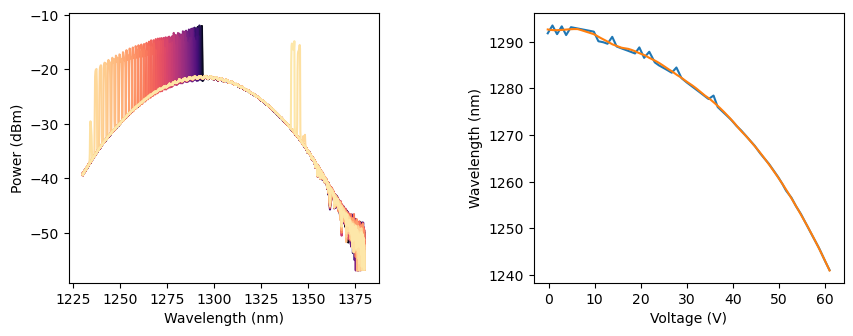

In [4]:
name="GSDev1a_9.2mW"
sample_dir=calib_dir
volt_stop=61*u.V
smooth_param=1000

# save_wavvolt(ds, volt_stop=volt_stop, smooth_param=smooth_param, name=None,sample_dir=None)
save_wavvolt(ds, volt_stop=volt_stop, smooth_param=smooth_param, name=name,sample_dir=sample_dir)

# DAQ Continuous Sweep

In [25]:
sample_dir = 'DAQcontSweep_diamond'
# name = 'diamond_sweep_VOA_wavvolt-trunc_OE71mW_Dev1a8.5mW_best'
name = 'Diamond_powder_test'

t_lia = 3*u.ms
sens_lia = 300 * u.uV
wav_start = 1253*u.nm
wav_stop = 1290*u.nm
Δwav = 0.1*u.nm 
num_sweep = 5
fixed_wav = 1075.6*u.nm

ds = VCSEL_sweep_spectrum(wav_start, wav_stop, Δwav, num_sweep, t_lia, sens_lia, fixed_wav, sample_dir=sample_dir, name=name)


saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_DAQcontSweep_diamond_2025-03-31-20-25-07\Spectra_Diamond_powder_test_2025-03-31-21-55-55.h5
dumping item: num_sweep
non-array, non-list item without units
dumping item: t_lia
non-array, non-list item with units:
millisecond
dumping item: sens_lia
non-array, non-list item with units:
microvolt
dumping item: wav_start
non-array, non-list item with units:
nanometer
dumping item: wav_stop
non-array, non-list item with units:
nanometer
dumping item: Δwav
non-array, non-list item with units:
nanometer
dumping item: wavelength_set
dumping item: pump_wav
non-array, non-list item with units:
nanometer
sweep time: 45.61 second
start time: Mon Mar 31 21:55:55 2025
stop time: Mon Mar 31 21:56:41 2025
dumping item: Dev2/ao1
dumping item: Dev2/ao0
dumping item: Dev2/ai0
dumping item: Dev2/ai1
dumping item: t
dumping item: Vsrs_arr
dumping item: HV_arr
dumping item: wav_est_arr
dumping item: Vsrs_interp_arr
dumping item: HVA_Vraw

In [213]:
sample_dir = "Sample_DAQcontSweep_diamond_2025-03-31-20-25-07"
filename = "Spectra_findDiamond_2025-03-31-20-25-07.h5"
ds = load_data_from_file(sample_dir, filename)
wavvolt_HVCALIB = os.path.join(calib_dir, "wavvolt_HVCALIB_GSDev1a_9.2mW_2025-3-31.mat") #For post-acquisition wavelength calibration

loading file: Spectra_findDiamond_2025-03-31-20-25-07.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VOA_Vset...
importing Vsrs_Vraw...
importing Vsrs_arr...
importing Vsrs_interp_arr...
importing raman_shift...
importing t...
importing wav_est_arr...
importing wavelength_set...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
microvolt
importing attr sens_lia_units...
importing attr t_lia...
millisecond
importing attr t_lia_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
importing attr Δwav...
nanometer
importing attr Δwav_units...


<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:51: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:51: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
C:\Users\euyehara\AppData\Local\Temp\ipykernel_15804\2152782965.py:49: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_ylabel("Voltage $(\mu V)$")
C:\Users\euyehara\AppData\Local\Temp\ipykernel_15804\2152782965.py:51: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_ylabel("Voltage $(\mu V)$")
C:\Users\euyehara\AppData\Local\Temp\ipykernel_15804\2152782965.py:54: SyntaxWarning: invalid escape sequence '\m'
  ax[2].set_ylabel("Voltage $(\mu V)$")


Peak at 1331.548 / centimeter


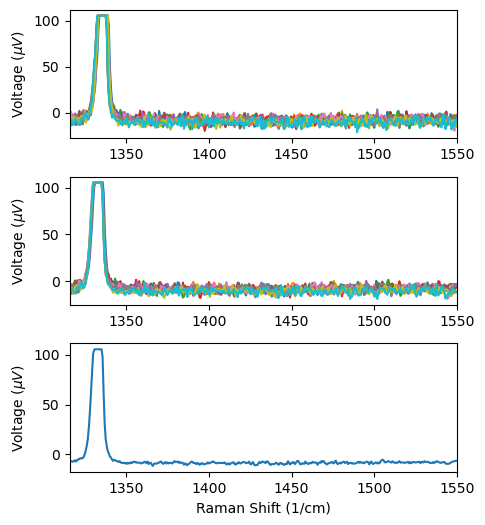

In [214]:
def plot_daq_sweepSpectra(ds, fname, fpath=False, figsize=(5,6), wavvolt_HVCALIB=wavvolt_HVCALIB):
    """
    Plot daq continuous sweep spectra. 3 Subplots: (1) Raw spectra, (2) Wavelength corrected from measured voltages, (3) Averaged corrected
    """
    def line(x,a,b):
        return a*x + b

    #Remove first point in sweep
    HVA_Vset = ds["HVA_Vset"][:-1]
    wavelength_set = ds["wavelength_set"][:-1]
    HV_arr = ds["HV_arr"][:,:-1]
    raman_shift = ds["raman_shift"][:-1]
    offset = 0*u.V
    Vsrs_arr = (ds["Vsrs_arr"][:,:-1] / 10 + offset).to(u.V).m * ds["sens_lia"].to(u.V)
    HV_filt = np.array(np.zeros(HV_arr.shape))
    wav_calib_arr = np.array(np.zeros(HV_arr.shape))
    Vsrs_interp_arr = np.array(np.zeros(HV_arr.shape))
    
    for spec in range(HV_arr.shape[0]):
        popt,_ = curve_fit(line,HVA_Vset.to(u.V).m,HV_arr[spec].to(u.V).m)
        HV_filt[spec] = line(HVA_Vset.m, popt[0], popt[1])
    HV_filt = HV_filt*u.V 
    
    # Calibrate voltage to wavelength
    a = io.loadmat(wavvolt_HVCALIB)
    wav_calib =  (a['peak_interp'][0] * u.m).to(u.nm)
    volt_calib = a['volt_interp'][0]*u.V
    
    # Find wavelengths corresponding to measured voltage 
    for sweep_iter in range(HV_filt.shape[0]):
        for wl in range(HV_filt.shape[1]):
            ind = np.argmin(np.abs(HV_filt[sweep_iter, wl].m - volt_calib.m))
            wav_calib_arr[sweep_iter, wl] = wav_calib[ind].m
            
        # Interpolate wavelength vs spectra to uniformly sample in wavelength
        Vsrs_interp_arr[sweep_iter,:] = np.interp(wavelength_set.to(u.nm).m, wav_calib_arr[sweep_iter,:], Vsrs_arr[sweep_iter,:].m)
    Vsrs_interp_arr = Vsrs_interp_arr*u.V
    Vsrs_av = np.mean(Vsrs_interp_arr, axis=0)
    mind = np.argmax(Vsrs_av)
    print("Peak at {:2.3f}".format(raman_shift[mind]))
    
    fig, ax = plt.subplots(3, 1, figsize=figsize, gridspec_kw={"wspace":0,"hspace":0.3})
    for spec in range(Vsrs_arr.shape[0]):
        ax[0].plot(raman_shift, Vsrs_arr[spec].to(u.uV))
        ax[1].plot(raman_shift, Vsrs_interp_arr[spec].to(u.uV))
        # ax[3].plot(HVA_Vset, HV_arr[spec].to(u.V))
        # ax[3].plot(HVA_Vset, HV_filt[spec].to(u.V))
    ax[2].plot(raman_shift, Vsrs_av.to(u.uV))
    ax[0].set_ylabel("Voltage $(\mu V)$")
    ax[0].set_xlim((np.min(raman_shift.m), np.max(raman_shift.m)))
    ax[1].set_ylabel("Voltage $(\mu V)$")
    ax[1].set_xlim((np.min(raman_shift.m), np.max(raman_shift.m)))
    ax[2].set_xlabel("Raman Shift (1/cm)")
    ax[2].set_ylabel("Voltage $(\mu V)$")
    ax[2].set_xlim((np.min(raman_shift.m), np.max(raman_shift.m)))

    if fpath:
        fname=os.path.normpath(os.path.join(fpath,fname))
        plt.savefig(fname, dpi=None, facecolor=None, edgecolor=None,
            orientation='portrait', transparent=True, bbox_inches=None, pad_inches=0.5)
    return fig

fname = "Spectra_findDiamond_2025-03-31-20-25-07"
fpath = os.path.join(data_dir,sample_dir)
fig = plot_daq_sweepSpectra(ds, fname, fpath=fpath)



# DAQ Step Sweep

In [11]:
osa = initialize_osa(ref_level = -43*u.dimensionless, wav_start=1050*u.nm, wav_stop = 1300*u.nm)

In [16]:
#Test DAQ VCSEL step sweep
sample_dir = 'Test_DAQ_VCSEL_sweep'
# name = 'diamond_sweep_VOA_wavvolt-trunc_OE71mW_Dev1a8.5mW_best'
name = 'testGS_sweep_MM_full'

t_lia = 30*u.ms
sens_lia = 300 * u.uV
wav_start = 1253*u.nm
wav_stop = 1290*u.nm
Δwav = 1*u.nm 
wav_settle_time = 0.3*u.s
num_avg = 5
fixed_wav = 1075.6*u.nm

calib_dir = 'C:\\Users\\euyehara\\experiment_control\\calibration_data\\VCSEL_calibration\\'
wavvolt_file = calib_dir + 'wavvolt-trunc_Dev1a_25C_OEland1076_5.72mW_2025-3-17.mat'
delayvolt_file = calib_dir + 'delayvolt3.mat'


ds = VCSEL_step_spectrum(osa, wavvolt_file, delayvolt_file, num_avg, t_lia, sens_lia, wav_start, wav_stop, Δwav, fixed_wav, wav_settle_time=1*u.s,sample_dir=sample_dir, name=name)
# ds = VCSEL_step_spectrum(osa, num_avg, t_lia, sens_lia, wav_start, wav_stop, Δwav, fixed_wav, wav_settle_time=1*u.s,sample_dir=sample_dir, name=name)

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_Test_DAQ_VCSEL_sweep_2025-03-25-18-27-43\Spectra_testGS_sweep_MM_full_2025-03-26-19-07-01.h5
dumping item: num_avg
non-array, non-list item without units
dumping item: t_lia
non-array, non-list item with units:
millisecond
dumping item: sens_lia
non-array, non-list item with units:
microvolt
dumping item: wav_start
non-array, non-list item with units:
nanometer
dumping item: wav_stop
non-array, non-list item with units:
nanometer
dumping item: Δwav
non-array, non-list item with units:
nanometer
dumping item: wav_settle_time
non-array, non-list item with units:
second
dumping item: wavelength_set
dumping item: fixed_wav
non-array, non-list item with units:
nanometer
sweep time: 60.80 second
start time: Wed Mar 26 19:07:11 2025
stop time: Wed Mar 26 19:08:12 2025
dumping item: spec
dumping item: daq_Vset
dumping item: HVA_Vset
dumping item: VOA_Vset
dumping item: V_mon
dumping item: raman_shift
dumping item: pump_wl_

# Single Wavelength Measurement

In [191]:
sample_dir = "PhotonicsWest-SNR-LIAnoiseMeas_diamond_SRL_point"
# name = "R_ycut-LN_DSP_Y(cZ)Y_30ms3uV_O110mW_S27mW_986"
name = "VaryDev1a_noise_SA-230F5_FGA21-25V_OE60mW_Dev1a0mW_3ms100uV"
# name = "OElandSweep_T_30ms3uV_120s_985_HWP_SHG-LP_50mW_noF-F"

t_lia = 3*u.ms
n_rep = 50
pump_wav = 1072.6*u.nm
stokes_wav = 1251.7*u.nm

ds_point = acquire_point(t_lia, n_rep, pump_wav, stokes_wav, sample_dir=sample_dir, name=name)


saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_PhotonicsWest-SNR-LIAnoiseMeas_diamond_SRL_point_2024-12-14-21-35-34\WavePoint_VaryDev1a_noise_SA-230F5_FGA21-25V_OE60mW_Dev1a0mW_3ms100uV_2024-12-15-16-39-49.h5
dumping item: t_lia
non-array, non-list item with units:
millisecond
dumping item: fsamp
non-array, non-list item with units:
hertz
dumping item: pump_wav
non-array, non-list item with units:
nanometer
dumping item: stokes_wav
non-array, non-list item with units:
nanometer
acquisition time: 600.00 millisecond
start time: Sun Dec 15 16:39:49 2024
stop time: Sun Dec 15 16:49:49 2024
dumping item: srs
loading file: WavePoint_VaryDev1a_noise_SA-230F5_FGA21-25V_OE60mW_Dev1a0mW_3ms100uV_2024-12-15-16-39-49.h5
importing srs...
importing attr fsamp...
hertz
importing attr fsamp_units...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr stokes_wav...
nanometer
importing attr stokes_wav_units...
importing attr t_lia...
millisecond


# Source Meter Step Sweep

In [3]:
osa = initialize_osa(ref_level = -43*u.dimensionless, wav_start=1050*u.nm, wav_stop = 1300*u.nm)

In [35]:
[pk_wls, _] = osa.get_peak_info()
print(pk_wls[0])
print(pk_wls[1])

1.0756e-06 meter
1.2631e-06 meter


In [5]:
span = 1300*u.nm - 1230*u.nm
center_wl = np.round(span/2) + 1250*u.nm
osa.set_wavelength_span(span)
osa.set_center_wavelength(center_wl)

In [22]:
sample_dir = 'Test_VCSEL_sweep'
name = 'diamond_sweep_VOA_wavvolt-trunc_OE71mW_Dev1a8.5mW_best'

t_lia = 30*u.ms
sens_lia = 300 * u.uV
wav_start = 1253*u.nm
wav_stop = 1290*u.nm
Δwav = 0.2*u.nm 
wav_settle_time = 0.3*u.s
num_avg = 5
fixed_wav = 1075.6*u.nm


ds_spec = acquire_spectrum(osa, num_avg, t_lia, sens_lia, wav_start, wav_stop, Δwav, fixed_wav, wav_settle_time=wav_settle_time, sample_dir=sample_dir, name=name)


saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_Test_VCSEL_sweep_CW_2025-03-21-16-46-04\Spectra_diamond_sweep_VOA_wavvolt-trunc_OE71mW_Dev1a8.5mW_best_2025-03-21-19-06-58.h5
dumping item: num_avg
non-array, non-list item without units
dumping item: t_lia
non-array, non-list item with units:
millisecond
dumping item: sens_lia
non-array, non-list item with units:
microvolt
dumping item: wav_start
non-array, non-list item with units:
nanometer
dumping item: wav_stop
non-array, non-list item with units:
nanometer
dumping item: Δwav
non-array, non-list item with units:
nanometer
dumping item: wav_settle_time
non-array, non-list item with units:
second
dumping item: wavelength_set
dumping item: fixed_wav
non-array, non-list item with units:
nanometer
sweep time: 304.00 second
start time: Fri Mar 21 19:07:08 2025
stop time: Fri Mar 21 19:12:12 2025
[55.3867 55.2758 55.1506 55.0389 54.927 54.8049 54.6926 54.5682 54.4564 54.3313 54.2193 54.0975 53.9855 53.8612 53.7367 53

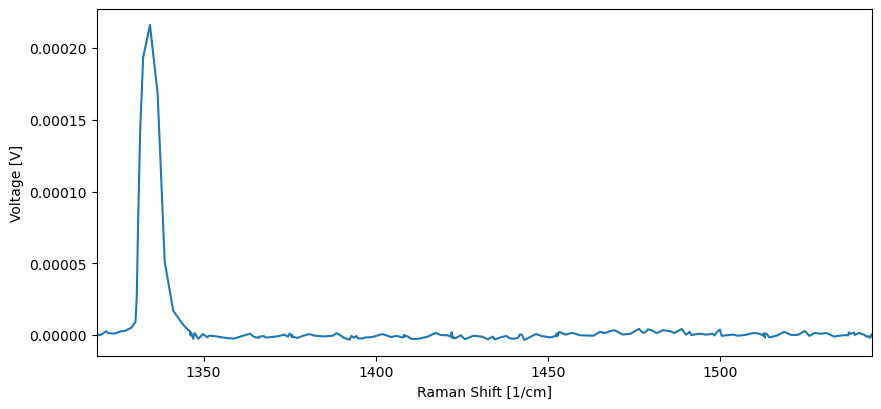

In [23]:
fig=plot_spectra(ds_spec, sg_win_len=10)


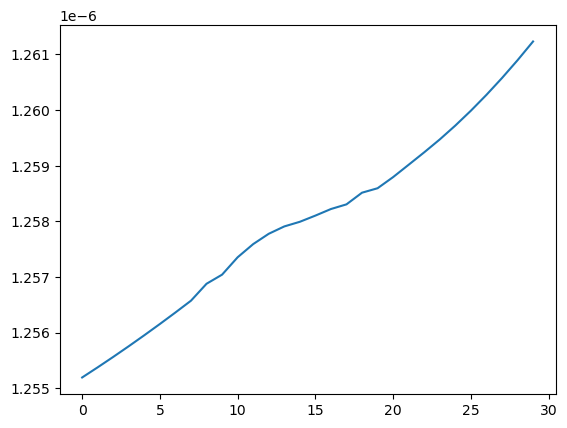

In [17]:
plt.figure()
ind_arr = np.arange(0, s_wl.shape[0],1)
s_wl = savgol_filter(ds_spec["stokes_wl_meas"].m, 15,2)*u.m
plt.plot(ind_arr,s_wl)

# Continuous Sweep Spectrum

In [10]:
sample_dir2 = "Test_VCSEL_sweep_CW"
name = "findDiamondsig"

t_lia = 10*u.ms
sens_lia = 100*u.uV
t_sweep = 120*1*u.s
wav_start = 1037.9*u.nm
wav_stop = 1080*u.nm
fixed_wav = 1256.4*u.nm
ds_spec = continuous_spectrum(t_lia, sens_lia, wav_start, wav_stop, fixed_wav, t_sweep=t_sweep,sample_dir=sample_dir2, name=name)
# ds_spec = continuous_spectrum_tap(t_lia, sens_lia, wav_start, wav_stop, fixed_wav, t_sweep=t_sweep,sample_dir=sample_dir2, name=name)

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_Test_VCSEL_sweep_CW_2025-03-21-16-46-04\SpectraSweep_findDiamondsig_2025-03-31-19-35-48.h5
dumping item: t_lia
non-array, non-list item with units:
millisecond
dumping item: sens_lia
non-array, non-list item with units:
microvolt
dumping item: fsamp
non-array, non-list item with units:
hertz
dumping item: wav_start
non-array, non-list item with units:
nanometer
dumping item: wav_stop
non-array, non-list item with units:
nanometer
dumping item: t_sweep
non-array, non-list item with units:
second
dumping item: fixed_wav
non-array, non-list item with units:
nanometer
sweep time: 120.00 second
start time: Mon Mar 31 19:35:48 2025
stop time: Mon Mar 31 19:37:48 2025
dumping item: spec
dumping item: wav_mon
loading file: SpectraSweep_findDiamondsig_2025-03-31-19-35-48.h5
importing spec...
importing wav_mon...
importing attr fixed_wav...
nanometer
importing attr fixed_wav_units...
importing attr fsamp...
hertz
importing a

# Knife Edge Scan

In [4]:
cam.close()
stage = initialize_stage()
stage.connect()

Connecting to BPC203:
	- connecting to controller 71829423 --> done
	- connecting channel 1 (x axis) --> done
	- connecting channel 2 (y axis) --> done
	- connecting channel 3 (z axis) --> done




In [3]:
wf_illum_off()

In [5]:
pos = stage.get_axis_position('y')

In [79]:
stage.set_axis_position('y', 7)

	- moving y axis piezo to 7.000000 um --> done


In [90]:
stage.set_axis_position('y', 15)

	- moving y axis piezo to 15.000000 um --> done


In [91]:
stage.set_axis_position('y', 0)

	- moving y axis piezo to 0.000000 um --> done


σ = 1.33μm


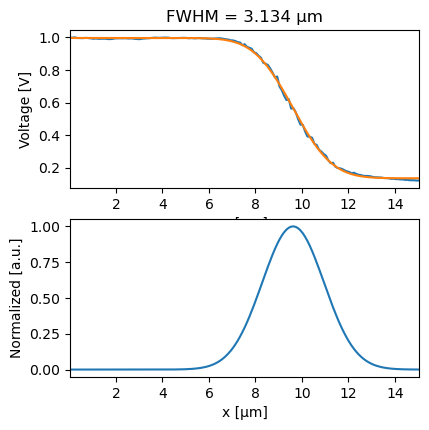

In [117]:
fig = plot_knife_scan(ds_spot)

In [116]:
scan_length = 15*u.um
axis = 'y'
step_size = 0.1*u.um
num_avg  = 3
# [ps_arr, pd_arr] = scan_single_axis(scan_length, axis, step_size, wait=0.5*u.s)
# ds_spot = knife_edge_scan(stage, scan_length, axis, step_size, num_avg=num_avg, sample_dir='Nikon20xR_y_SiAu', name='Solstis985_pos38')
ds_spot = knife_edge_scan(stage, scan_length, axis, step_size, num_avg=num_avg, sample_dir='BeamSpotMeas_Nikon20xT_y_GaAs', name='Dev1a-redo_Coverslip_pos47')

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_BeamSpotMeas_Nikon20xT_y_GaAs_2024-12-14-12-14-28\knifeScan_Dev1a-redo_Coverslip_pos47_2024-12-14-17-53-04.h5
15.033570360423598
scan time: 302.00 second
start time: Sat Dec 14 17:53:04 2024
stop time: Sat Dec 14 17:58:06 2024
	- moving y axis piezo to 0.033570 um --> done
	- moving y axis piezo to 0.133570 um --> done
	- moving y axis piezo to 0.233570 um --> done
	- moving y axis piezo to 0.333570 um --> done
	- moving y axis piezo to 0.433570 um --> done
	- moving y axis piezo to 0.533570 um --> done
	- moving y axis piezo to 0.633570 um --> done
	- moving y axis piezo to 0.733570 um --> done
	- moving y axis piezo to 0.833570 um --> done
	- moving y axis piezo to 0.933570 um --> done
	- moving y axis piezo to 1.033570 um --> done
	- moving y axis piezo to 1.133570 um --> done
	- moving y axis piezo to 1.233570 um --> done
	- moving y axis piezo to 1.333570 um --> done
	- moving y axis piezo to 1.433570 um --> d

In [39]:
move_spot(0.3*u.volt, -0.3*u.volt)

In [40]:
move_spot(-0.3*u.volt, 0.3*u.volt)

In [41]:
center_spot()

# Galvo Scan

scan time: 270.00 second


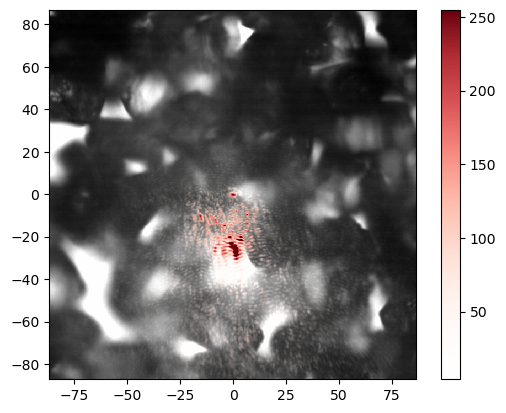

In [43]:
# Configure scan and preview scan area
# 3ms integration time
filename = "diamondPowder_GSDev1a-1255.9_OEland1075.6-68mW_300uV3ms_zscan2_34" 
sample_dir = "GSDev1a"

t_LIA = 3*u.ms
nx, ny      =   150   ,   150 #500          ,       500
ΔVx, ΔVy    =   1.0*u.volt   ,   1.0*u.volt #1.0*u.volt    ,      1.0*u.volt # 0.8*u.volt
fsamp       =   (1/(4*t_LIA)).to(u.Hz)#1000*u.Hz

fig = preview_scan_area(nx, ny, ΔVx, ΔVy, fsamp=fsamp, exposure_time=7*u.ms)

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_GSDev1a_2025-03-31-22-06-09\GalvoScan_diamondPowder_GSDev1a-1255.9_OEland1075.6-68mW_300uV3ms_zscan2_34_2025-04-03-21-43-00.h5
dumping item: wf_img
dumping item: laser_spot_img
dumping item: dx_dpix
non-array, non-list item with units:
micrometer
dumping item: x_img
dumping item: y_img
dumping item: dx_dVx
non-array, non-list item with units:
micrometer / volt
dumping item: dy_dVy
non-array, non-list item with units:
micrometer / volt
dumping item: Vx0
non-array, non-list item with units:
volt
dumping item: Vy0
non-array, non-list item with units:
volt
scan time: 270.00 second
start time: Thu Apr  3 21:43:02 2025
stop time: Thu Apr  3 21:47:32 2025
dumping item: Dev1/ao0
dumping item: Dev1/ao1
dumping item: Dev1/ao2
dumping item: Dev1/ao3
dumping item: Dev1/ai0
dumping item: Dev1/ai2
dumping item: Dev1/ai3
dumping item: t
dumping item: Vx
dumping item: Vy
dumping item: dx_dVx
non-array, non-list item with units:
mi

C:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:733: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.array(x, subok=True, copy=copy)


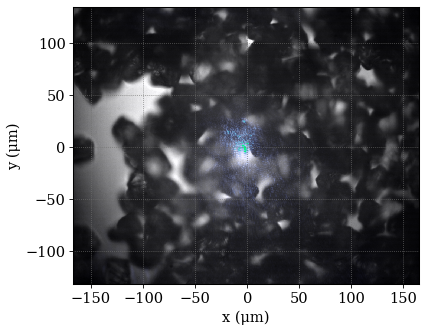

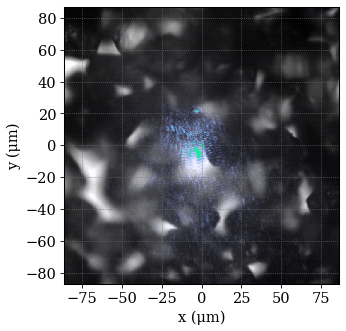

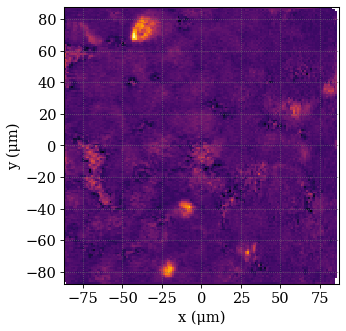

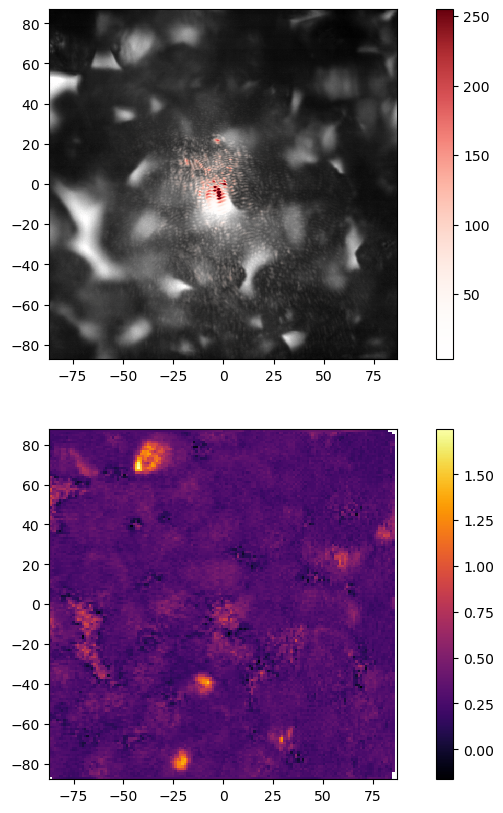

In [44]:
ds0 = collect_wfscan(nx,ny,ΔVx,ΔVy,Vx0,Vy0,fsamp,name=filename,sample_dir=sample_dir,wf_exposure_time=5*u.ms)
fig = plot_scan_data(ds0, wf_cmap=cm.gray, laser_cmap=cm.Reds, srs_cmap=cm.inferno)

# Manual widefield image+ scan

scan time: 900.00 second


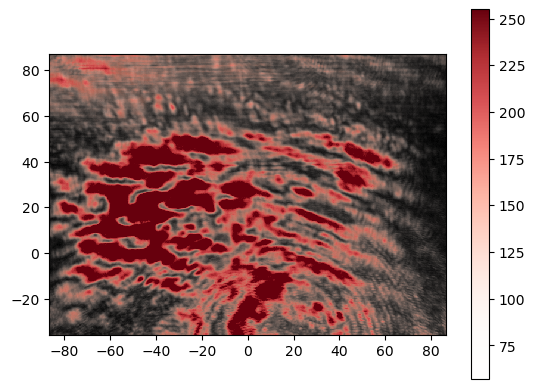

In [14]:
sample_dir= "GSDev1a" 
filename = "diamondPowder_GSDev1a-1256.8_OEland1075.6-71mW_300uV3ms_manual"

t_LIA = 3*u.ms
nx, ny      =   150   ,   150 #500          ,       500
ΔVx, ΔVy    =   1.0*u.volt   ,   1.0*u.volt #1.0*u.volt    ,      1.0*u.volt # 0.8*u.volt
fsamp       =   (1/(4*t_LIA)).to(u.Hz)#1000*u.Hz

fig = preview_scan_area(nx, ny, ΔVx, ΔVy, fsamp=fsamp, exposure_time=81*u.ms)

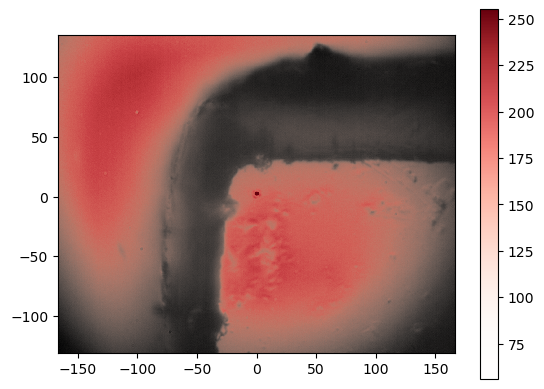

In [4]:
# Take laser spot and widefield image
wf_img, laser_spot_img = wf_and_laser_spot_images(exposure_time=81*u.ms)
fig = plot_laser_widefield_img(wf_img, laser_spot_img)

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_diamond_SRL_GSDev1a_OEland1075.6-70mW_Nikon20x_2025-03-21-20-29-02\GalvoScan_Dev1a-1255.81_300uV3ms_1V150N_maxUp_2025-03-21-22-26-34.h5
dumping item: wf_img
dumping item: laser_spot_img
dumping item: dx_dpix
non-array, non-list item with units:
micrometer
dumping item: x_img
dumping item: y_img
dumping item: dx_dVx
non-array, non-list item with units:
micrometer / volt
dumping item: dy_dVy
non-array, non-list item with units:
micrometer / volt
dumping item: Vx0
non-array, non-list item with units:
volt
dumping item: Vy0
non-array, non-list item with units:
volt
scan time: 900.00 second
start time: Fri Mar 21 22:26:34 2025
stop time: Fri Mar 21 22:41:34 2025
dumping item: Dev1/ao0
dumping item: Dev1/ao1
dumping item: Dev1/ao2
dumping item: Dev1/ao3
dumping item: Dev1/ai0
dumping item: Dev1/ai2
dumping item: Dev1/ai3
dumping item: t
dumping item: Vx
dumping item: Vy
dumping item: dx_dVx
non-array, non-list item with 

C:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:733: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.array(x, subok=True, copy=copy)


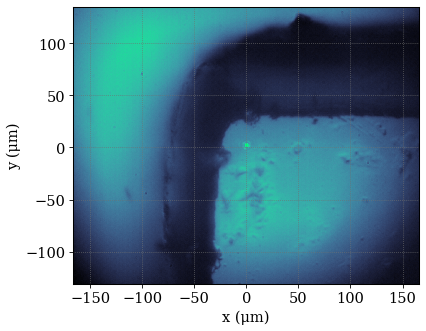

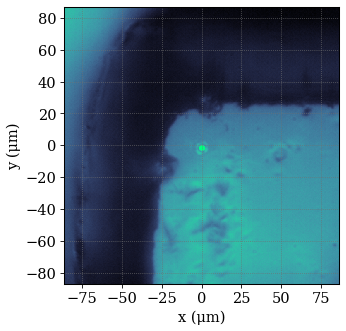

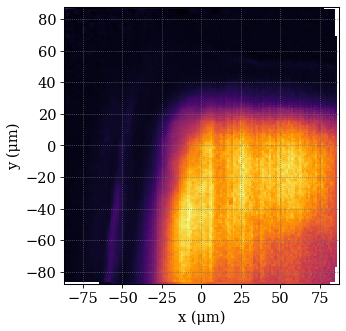

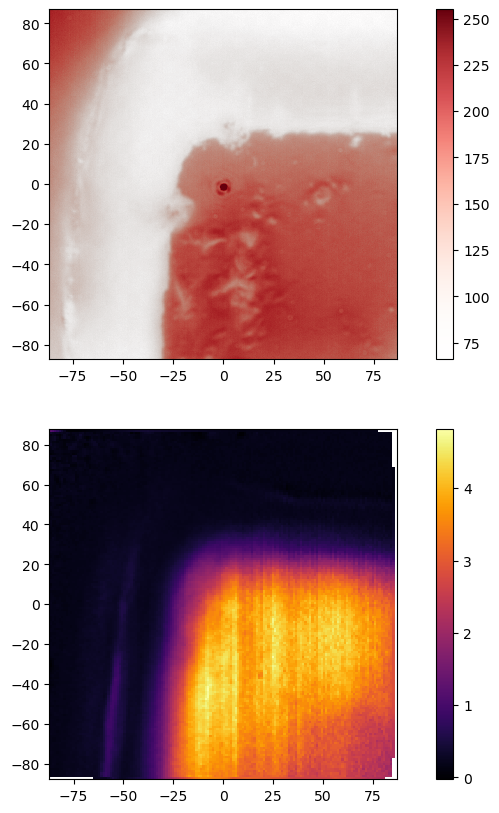

In [15]:
ds0 = collect_scan(nx,ny,ΔVx,ΔVy,Vx0,Vy0,fsamp,wf_img,laser_spot_img,name=filename,sample_dir=sample_dir)
fig = plot_scan_data(ds0, wf_cmap=cm.binary, laser_cmap=cm.Reds, srs_cmap=cm.inferno)